In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
print("Setup Successful!")

/Users/msreeja/Documents/ecommerce-image-intelligence/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Matplotlib is building the font cache; this may take a moment.


Setup Successful!


In [2]:
# Step 1: Import libraries
import requests              # used to download webpage
from bs4 import BeautifulSoup   # used to read HTML
import pandas as pd          # used to store data in table

# Step 2: Website URL (demo site for scraping practice)
url = "https://books.toscrape.com/catalogue/page-1.html"

# Step 3: Download the webpage
response = requests.get(url)

# Step 4: Convert webpage into readable HTML format
soup = BeautifulSoup(response.text, "html.parser")

# Step 5: Create empty list to store products
products = []

# Step 6: Find all product boxes on page
items = soup.select(".product_pod")

# Step 7: Loop through each product
for item in items:

    # Get product title
    title = item.h3.a["title"]

    # Get price
    price = item.select_one(".price_color").text

    # Get image link (relative link)
    image_link = item.img["src"]

    # Convert relative link to full link
    image_url = "https://books.toscrape.com/" + image_link.replace("../", "")

    # Store data in dictionary
    product_data = {
        "title": title,
        "price": price,
        "image_url": image_url
    }

    # Add to list
    products.append(product_data)

# Step 8: Convert list to DataFrame (table)
df = pd.DataFrame(products)

# Step 9: Show first rows
df.head()

,title,price,image_url
0,A Light in the Attic,Â£51.77,https://books.toscrape.com/media/cache/2c/da/2...
1,Tipping the Velvet,Â£53.74,https://books.toscrape.com/media/cache/26/0c/2...
2,Soumission,Â£50.10,https://books.toscrape.com/media/cache/3e/ef/3...
3,Sharp Objects,Â£47.82,https://books.toscrape.com/media/cache/32/51/3...
4,Sapiens: A Brief History of Humankind,Â£54.23,https://books.toscrape.com/media/cache/be/a5/b...


In [3]:
# Step 1: Import library
import os
import requests

# Step 2: Create folder to store images
folder_name = "images"
os.makedirs(folder_name, exist_ok=True)

# Step 3: Download first 20 images
for i, row in df.head(20).iterrows():

    try:
        # Get image URL
        image_url = row["image_url"]

        # Download image
        image_data = requests.get(image_url).content

        # Create file name
        file_path = f"{folder_name}/product_{i}.jpg"

        # Save image
        with open(file_path, "wb") as f:
            f.write(image_data)

        # Save file path in dataframe
        df.loc[i, "file_path"] = file_path

        print(f"Downloaded: {file_path}")

    except Exception as e:
        print("Failed to download:", row["title"])

Downloaded: images/product_0.jpg
Downloaded: images/product_1.jpg
Downloaded: images/product_2.jpg
Downloaded: images/product_3.jpg
Downloaded: images/product_4.jpg
Downloaded: images/product_5.jpg
Downloaded: images/product_6.jpg
Downloaded: images/product_7.jpg
Downloaded: images/product_8.jpg
Downloaded: images/product_9.jpg
Downloaded: images/product_10.jpg
Downloaded: images/product_11.jpg
Downloaded: images/product_12.jpg
Downloaded: images/product_13.jpg
Downloaded: images/product_14.jpg
Downloaded: images/product_15.jpg
Downloaded: images/product_16.jpg
Downloaded: images/product_17.jpg
Downloaded: images/product_18.jpg
Downloaded: images/product_19.jpg


In [4]:
df.head()

,title,price,image_url,file_path
0,A Light in the Attic,Â£51.77,https://books.toscrape.com/media/cache/2c/da/2...,images/product_0.jpg
1,Tipping the Velvet,Â£53.74,https://books.toscrape.com/media/cache/26/0c/2...,images/product_1.jpg
2,Soumission,Â£50.10,https://books.toscrape.com/media/cache/3e/ef/3...,images/product_2.jpg
3,Sharp Objects,Â£47.82,https://books.toscrape.com/media/cache/32/51/3...,images/product_3.jpg
4,Sapiens: A Brief History of Humankind,Â£54.23,https://books.toscrape.com/media/cache/be/a5/b...,images/product_4.jpg


In [5]:
# Image processing libraries
from PIL import Image
import cv2
import numpy as np
import os

In [6]:
# Create empty list to store image statistics
image_stats = []

# Loop through images we downloaded
for i, row in df.dropna().iterrows():

    try:
        # Open image using PIL
        img = Image.open(row["file_path"])

        # Resize image (fixed size)
        resized = img.resize((200, 300))

        # Convert to grayscale
        gray = resized.convert("L")

        # Convert grayscale image to numpy array (needed for OpenCV)
        gray_np = np.array(gray)

        # Edge detection using OpenCV
        edges = cv2.Canny(gray_np, 100, 200)

        # Extract features
        width, height = resized.size
        file_size = os.path.getsize(row["file_path"])
        brightness = gray_np.mean()

        # Save stats
        image_stats.append({
            "title": row["title"],
            "width": width,
            "height": height,
            "file_size": file_size,
            "brightness": brightness
        })

    except Exception as e:
        print("Error processing:", row["title"])

# Convert to DataFrame
stats_df = pd.DataFrame(image_stats)

# Show result
stats_df.head()

,title,width,height,file_size,brightness
0,A Light in the Attic,200,300,9876,216.119417
1,Tipping the Velvet,200,300,7095,57.219350
2,Soumission,200,300,4062,225.045250
3,Sharp Objects,200,300,8442,23.675933
4,Sapiens: A Brief History of Humankind,200,300,7986,235.403167


In [7]:
# Largest image (by file size)
largest = stats_df.loc[stats_df["file_size"].idxmax()]

# Smallest image
smallest = stats_df.loc[stats_df["file_size"].idxmin()]

# Brightest image
brightest = stats_df.loc[stats_df["brightness"].idxmax()]

# Darkest image
darkest = stats_df.loc[stats_df["brightness"].idxmin()]

# Average resolution
avg_width = stats_df["width"].mean()
avg_height = stats_df["height"].mean()

# Print results
print("Largest Image:", largest["title"])
print("Smallest Image:", smallest["title"])
print("Brightest Image:", brightest["title"])
print("Darkest Image:", darkest["title"])

print("\nAverage Resolution:")
print("Width:", avg_width)
print("Height:", avg_height)

Largest Image: Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Smallest Image: Olio
Brightest Image: Sapiens: A Brief History of Humankind
Darkest Image: The Black Maria

Average Resolution:
Width: 200.0
Height: 300.0


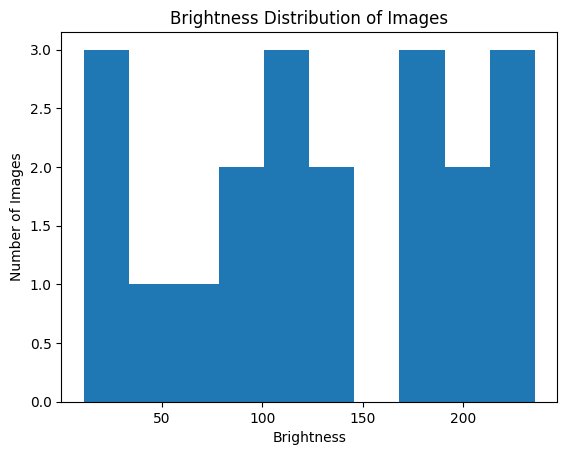

In [8]:
import matplotlib.pyplot as plt

# Histogram of brightness
plt.hist(stats_df["brightness"], bins=10)
plt.title("Brightness Distribution of Images")
plt.xlabel("Brightness")
plt.ylabel("Number of Images")
plt.show()

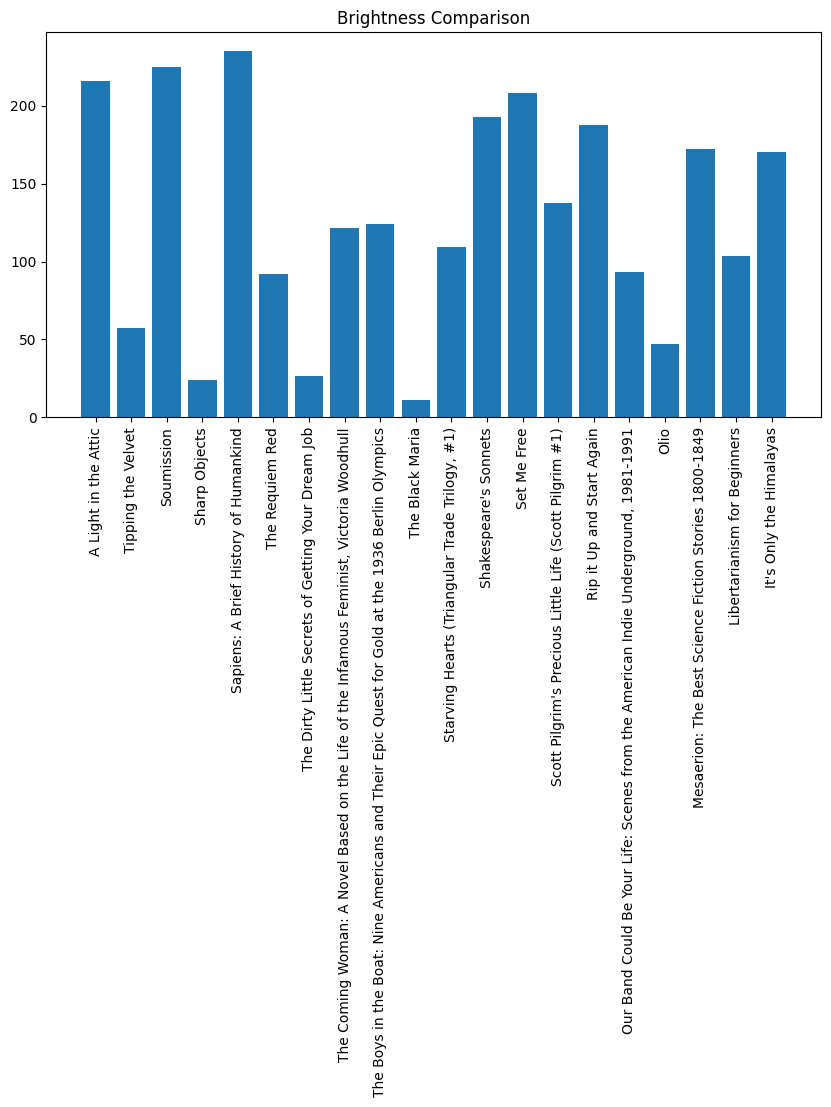

In [9]:
# Bar chart comparing brightness
plt.figure(figsize=(10,5))

plt.bar(stats_df["title"], stats_df["brightness"])

plt.title("Brightness Comparison")
plt.xticks(rotation=90)
plt.show()

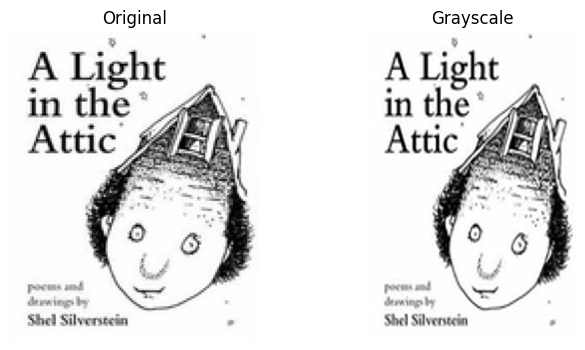

In [10]:
# Show one sample image processing result

sample_path = df.dropna().iloc[0]["file_path"]

img = Image.open(sample_path)
resized = img.resize((200,300))
gray = resized.convert("L")

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.show()

Project Findings

Product information such as title, price, and image URLs was successfully scraped from the demo e-commerce website Books to Scrape.

The downloaded product images were stored locally and organized into a structured dataset.

All images were resized to a fixed resolution to ensure consistency during analysis.

Image preprocessing techniques such as grayscale conversion and edge detection were applied successfully.

Brightness values varied across images, showing differences in visual appearance of product covers.

Some images had larger file sizes, indicating higher detail and complexity.

Edge detection highlighted important visual patterns such as text, shapes, and object boundaries on product images.

Basic image analytics such as largest image, smallest image, brightest image, darkest image, and average resolution were generated.

Visualizations including histogram and bar charts helped compare image brightness and understand overall distribution.

The project demonstrates an end-to-end pipeline combining web scraping, image processing, feature extraction, and data analysis.